<a href="https://www.kaggle.com/code/lalit7881/fake-news-detection-eda-100?scriptVersionId=338277702" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # ensure backend is set when using matplotlib
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # ensure proper backend if only plt is imported
%matplotlib inline

import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mobeenfatimah/fake-news-detection-dataset-6000-news-articles/news_dataset.csv


## loading dataset


In [2]:
df = pd.read_csv("/kaggle/input/datasets/mobeenfatimah/fake-news-detection-dataset-6000-news-articles/news_dataset.csv")

In [3]:
df.head()

,title,text,subject,date,label
0,WATCH: Trump Just Told All The Anti-Gay Bigot...,A whole lot of evangelical Trump voters just d...,News,"November 13, 2016",0
1,"China backs U.N. call for justice in Yemen, U....",GENEVA (Reuters) - China signaled on Wednesday...,worldnews,"September 13, 2017",1
2,THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...,,politics,"Feb 16, 2017",0
3,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...,politics,"Nov 15, 2015",0
4,Lawmakers aim to delay U.S. ceding control of ...,WASHINGTON (Reuters) - Critics of a plan for t...,politicsNews,"September 13, 2016",1


In [4]:
df.tail()

,title,text,subject,date,label
5995,Exiled Venezuelan opposition magistrates resur...,SANTIAGO (Reuters) - A group of opposition-app...,worldnews,"October 19, 2017",1
5996,Plague outbreak in Madagascar kills 20: WHO,NAIROBI (Reuters) - An outbreak of plague has ...,worldnews,"September 29, 2017",1
5997,"Trump to visit Asia in November, North Korea i...",WASHINGTON (Reuters) - Donald Trump will trave...,worldnews,"September 29, 2017",1
5998,Melania Trump calls taped comments by Donald T...,(Reuters) - Melania Trump rose to her husband’...,politicsNews,"October 18, 2016",1
5999,"#BoycottPenzeys: HATEFUL, DIVISIVE Penzeys Spi...","Bill Penzey, the owner of Penzeys Spices, wrot...",politics,"Dec 2, 2016",0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    6000 non-null   object
 1   text     6000 non-null   object
 2   subject  6000 non-null   object
 3   date     6000 non-null   object
 4   label    6000 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 234.5+ KB


In [6]:
df.describe()

,label
count,6000.000000
mean,0.500000
std,0.500042
min,0.000000
25%,0.000000
50%,0.500000
75%,1.000000
max,1.000000


In [7]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(5)

In [9]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [10]:
df.nunique()

title      5884
text       5830
subject       8
date       1911
label         2
dtype: int64

In [11]:
df.dtypes

title      object
text       object
subject    object
date       object
label       int64
dtype: object

## EDA

(6000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    6000 non-null   object
 1   text     6000 non-null   object
 2   subject  6000 non-null   object
 3   date     6000 non-null   object
 4   label    6000 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 234.5+ KB
None
                                                    title  text       subject  \
count                                                6000  6000          6000   
unique                                               5884  5830             8   
top     DISTURBING TRUTH ABOUT How The UN Decides Whic...        politicsNews   
freq                                                    3    64          1564   
mean                                                  NaN   NaN           NaN   
std                                                   NaN   NaN           NaN   
m

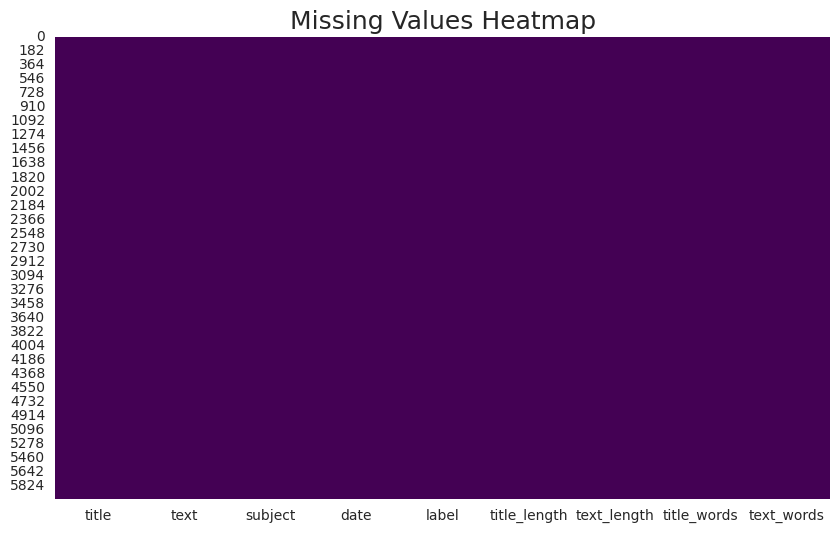

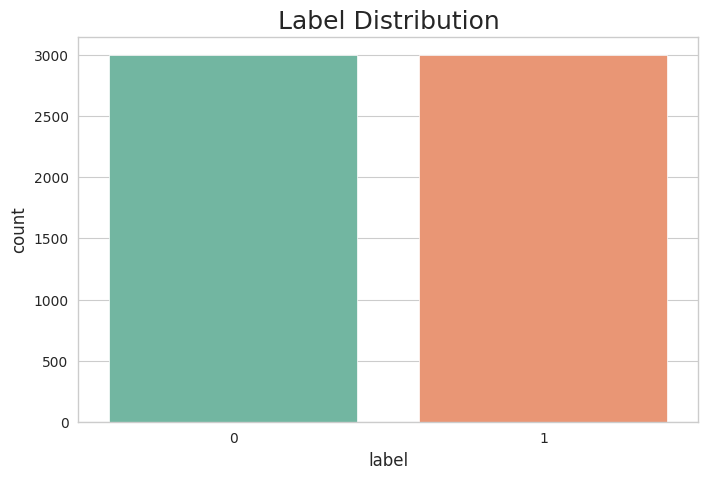

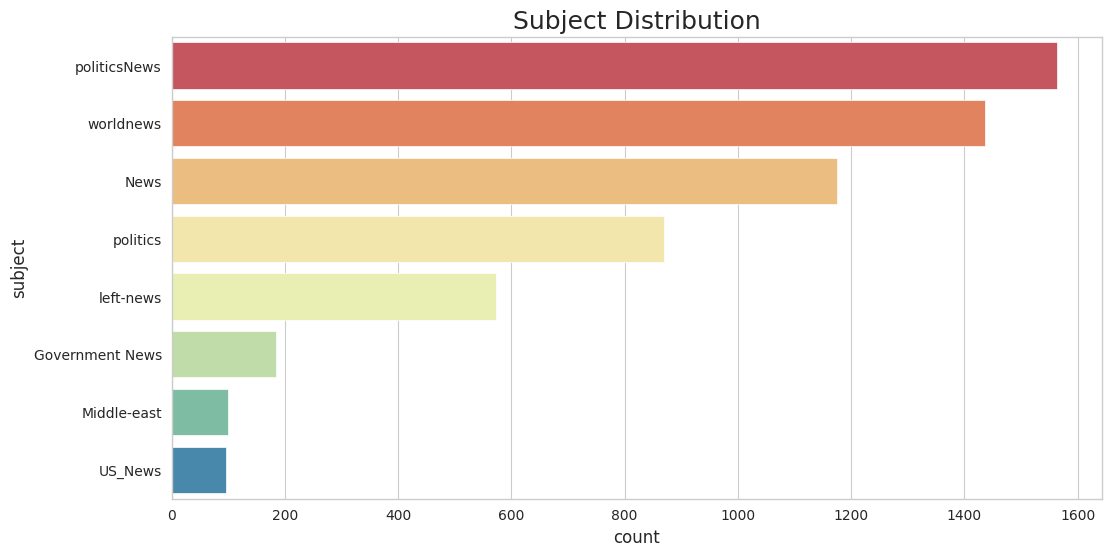

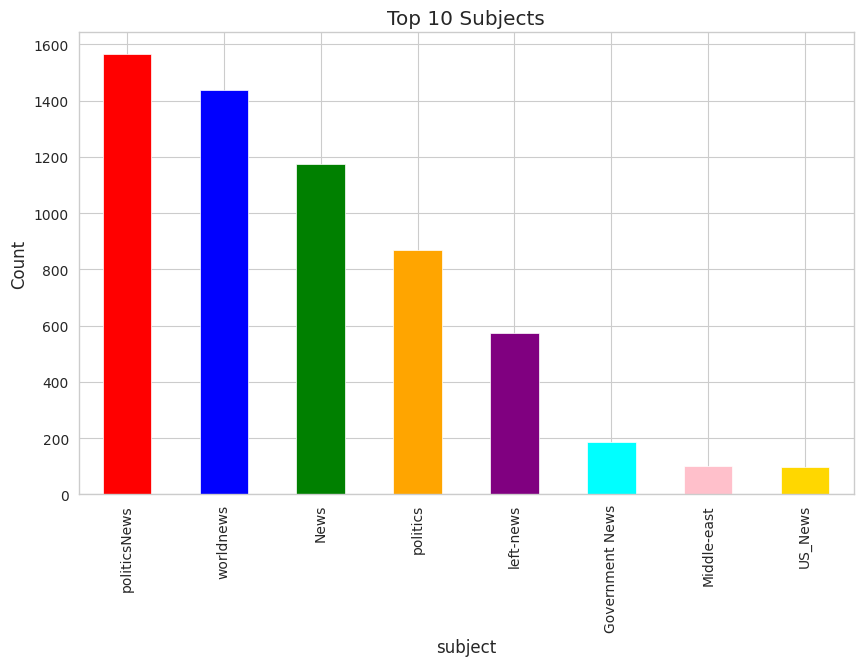

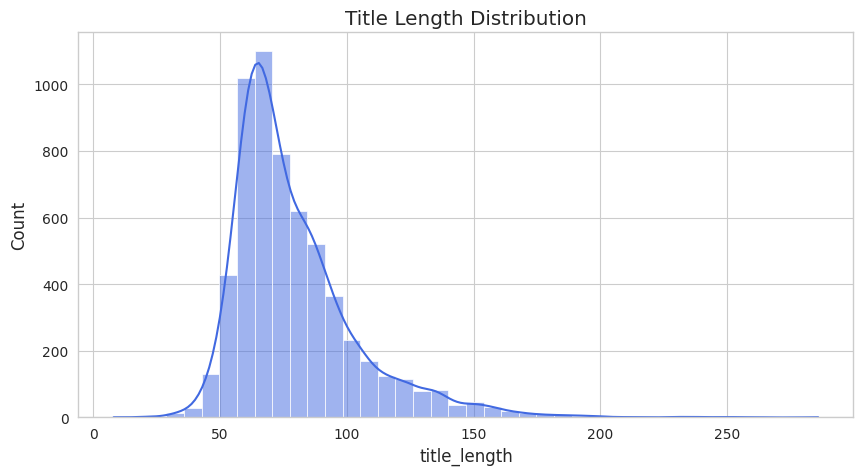

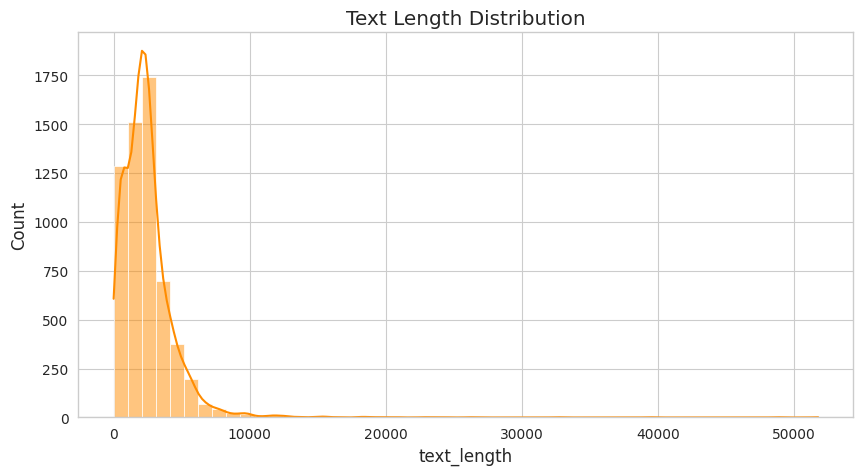

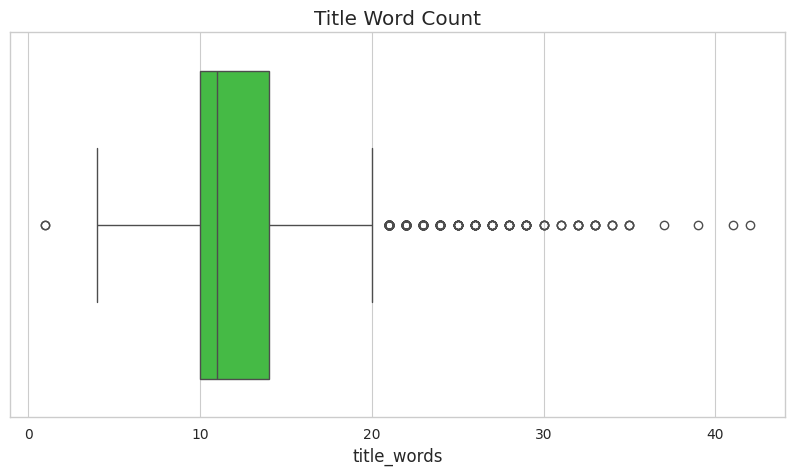

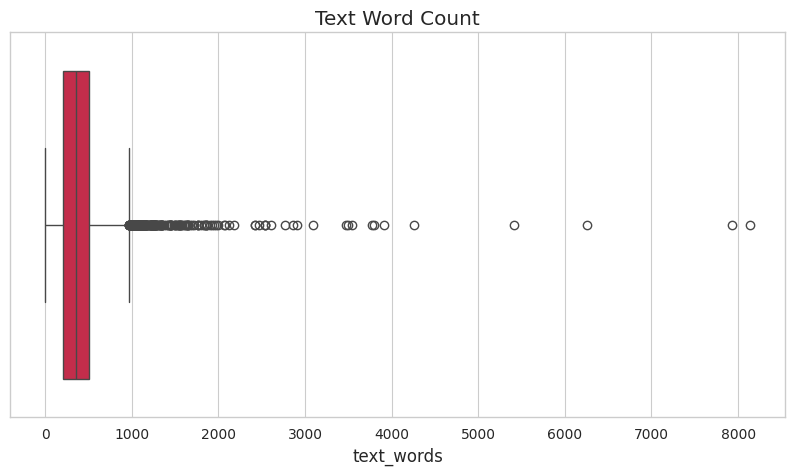

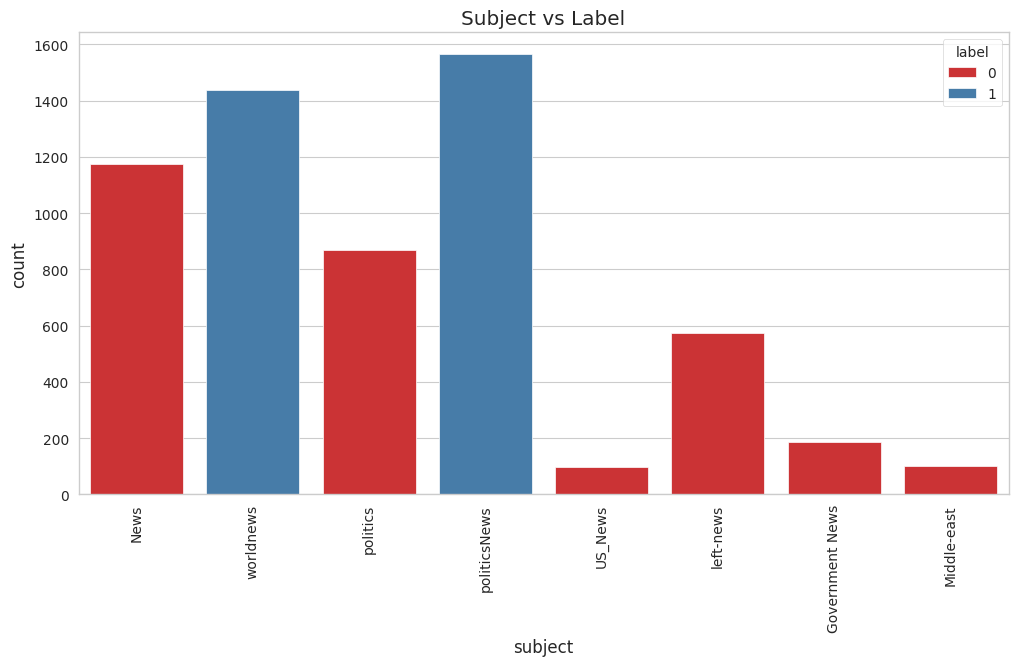

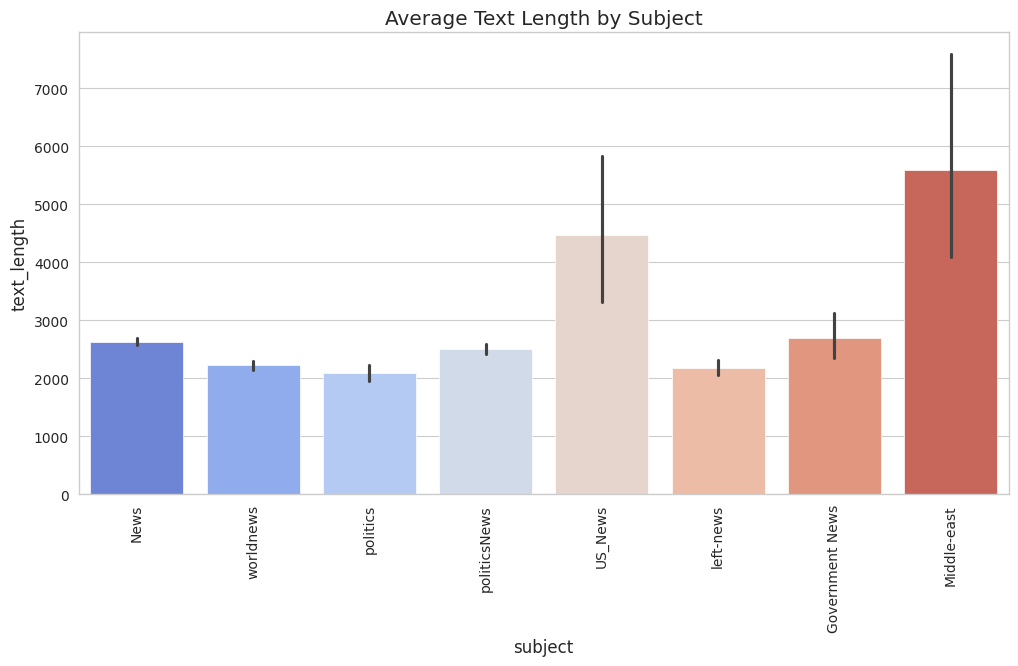

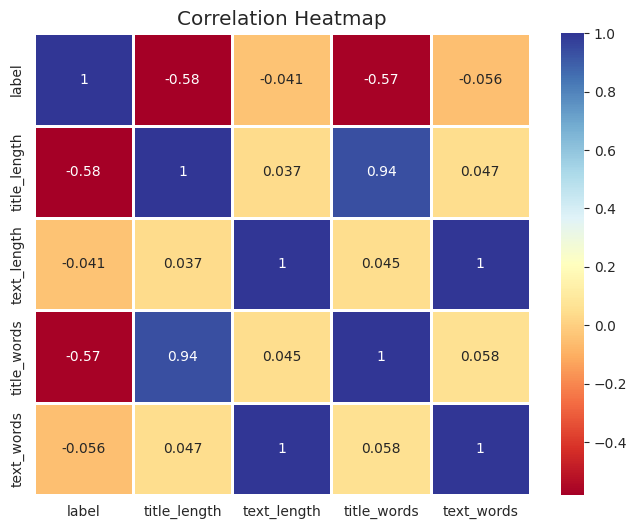

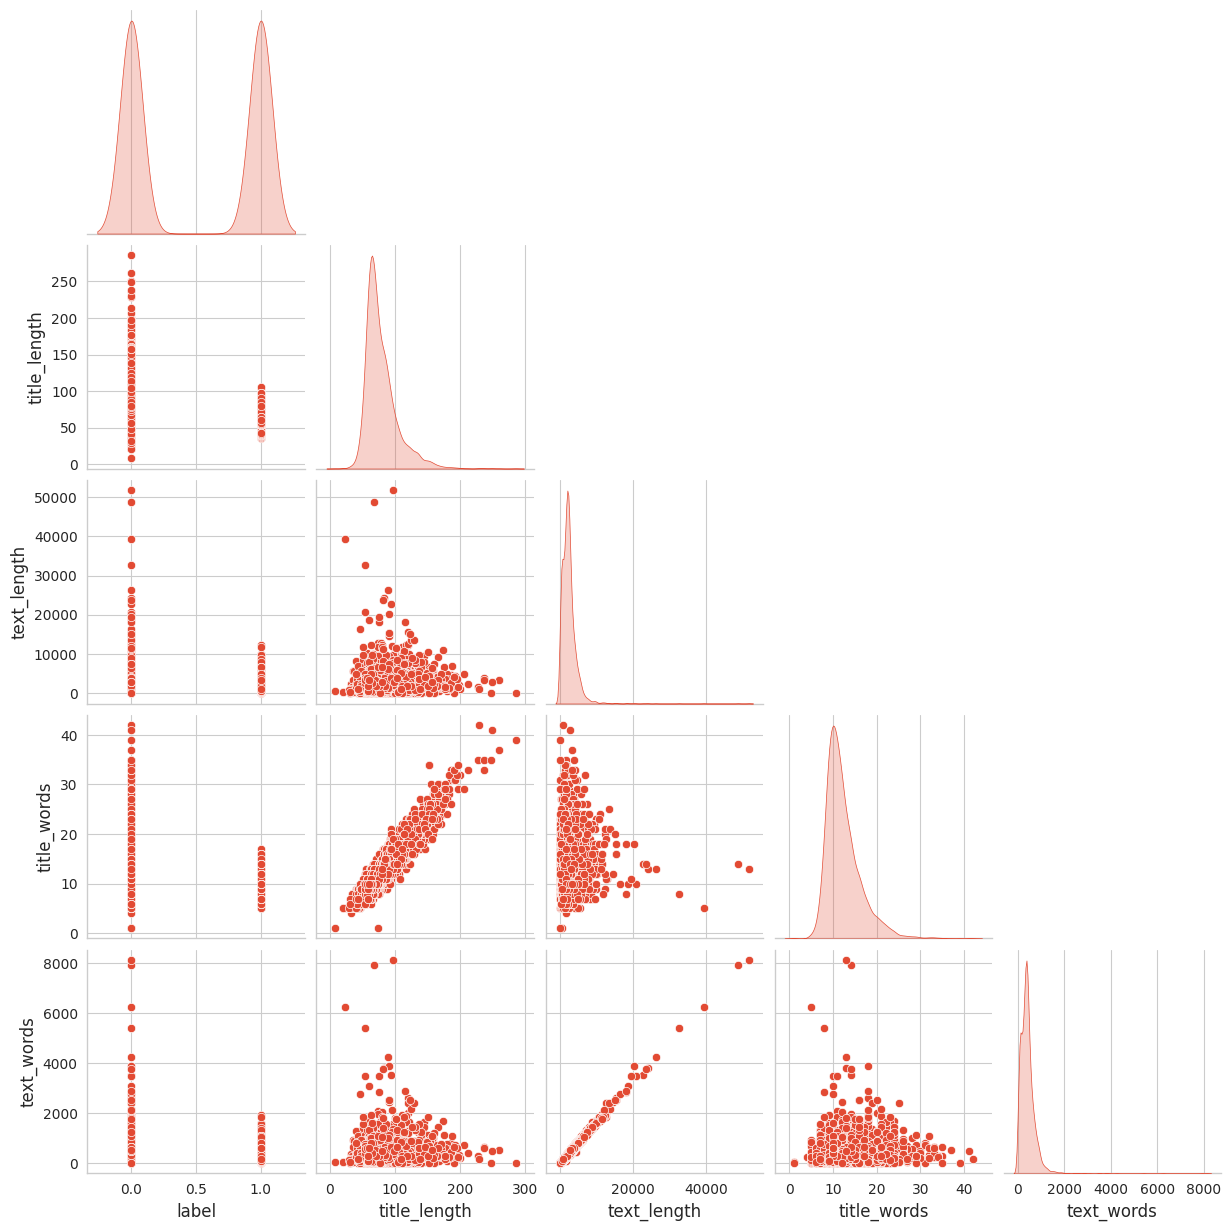

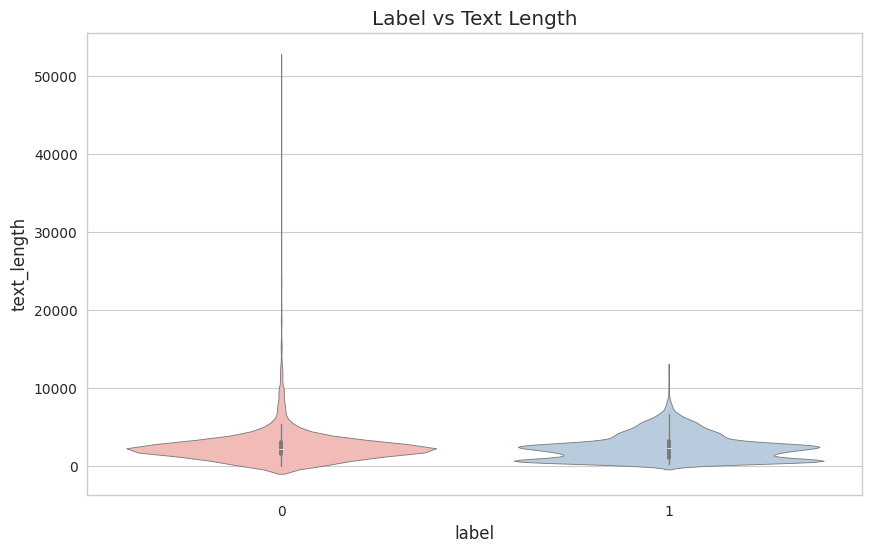

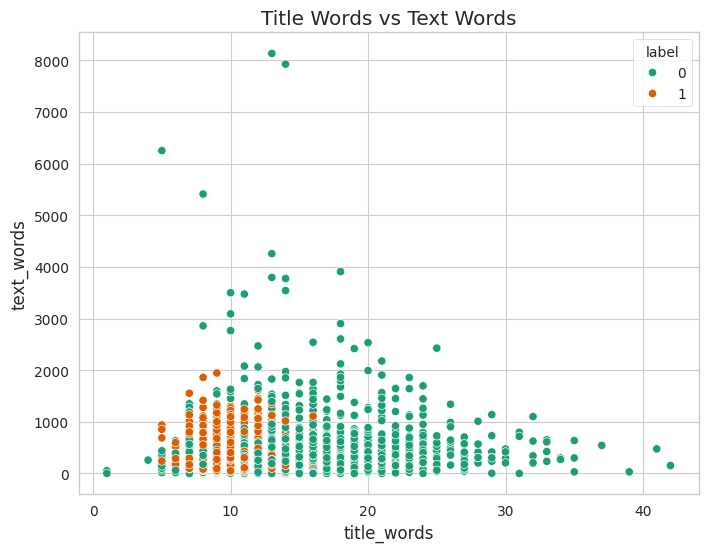

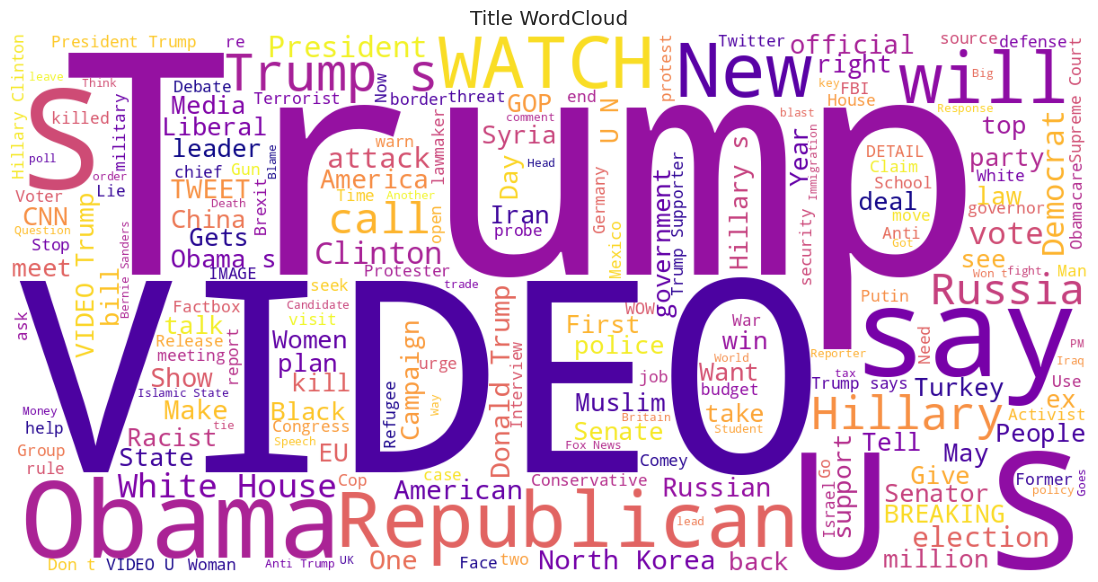

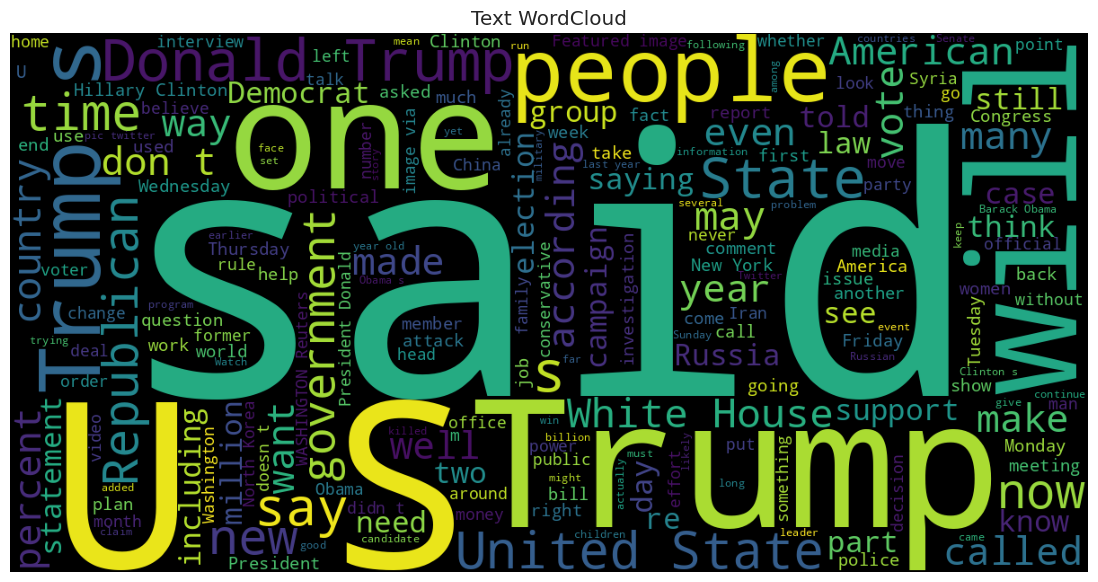

 All Visualizations Completed Successfully.


In [12]:

# Plotly
import plotly.express as px

# WordCloud
from wordcloud import WordCloud

# Style
plt.style.use("ggplot")
sns.set_style("whitegrid")

# ============================================================
# BASIC INFORMATION
# ============================================================

print(df.shape)
print(df.info())
print(df.describe(include='all'))

# ============================================================
# FEATURE ENGINEERING
# ============================================================

df["title_length"] = df["title"].astype(str).apply(len)
df["text_length"] = df["text"].astype(str).apply(len)
df["title_words"] = df["title"].astype(str).apply(lambda x: len(x.split()))
df["text_words"] = df["text"].astype(str).apply(lambda x: len(x.split()))

# ============================================================
# 1. Missing Values Heatmap
# ============================================================

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cmap="viridis", cbar=False)
plt.title("Missing Values Heatmap", fontsize=18)
plt.show()

# ============================================================
# 2. Label Distribution
# ============================================================

plt.figure(figsize=(8,5))
sns.countplot(data=df,
              x="label",
              palette="Set2")
plt.title("Label Distribution", fontsize=18)
plt.show()

# ============================================================
# 3. Subject Distribution
# ============================================================

plt.figure(figsize=(12,6))
sns.countplot(data=df,
              y="subject",
              palette="Spectral",
              order=df["subject"].value_counts().index)

plt.title("Subject Distribution", fontsize=18)
plt.show()

# ============================================================
# 4. Top 10 Subjects
# ============================================================

plt.figure(figsize=(10,6))

df["subject"].value_counts().head(10).plot(
    kind="bar",
    color=["red","blue","green","orange","purple",
           "cyan","pink","gold","brown","gray"]
)

plt.title("Top 10 Subjects")
plt.ylabel("Count")
plt.show()

# ============================================================
# 5. Title Length Distribution
# ============================================================

plt.figure(figsize=(10,5))
sns.histplot(df["title_length"],
             bins=40,
             color="royalblue",
             kde=True)

plt.title("Title Length Distribution")
plt.show()

# ============================================================
# 6. Text Length Distribution
# ============================================================

plt.figure(figsize=(10,5))
sns.histplot(df["text_length"],
             bins=50,
             color="darkorange",
             kde=True)

plt.title("Text Length Distribution")
plt.show()

# ============================================================
# 7. Title Words Distribution
# ============================================================

plt.figure(figsize=(10,5))
sns.boxplot(x=df["title_words"],
            color="limegreen")

plt.title("Title Word Count")
plt.show()

# ============================================================
# 8. Text Words Distribution
# ============================================================

plt.figure(figsize=(10,5))
sns.boxplot(x=df["text_words"],
            color="crimson")

plt.title("Text Word Count")
plt.show()

# ============================================================
# 9. Label vs Subject
# ============================================================

plt.figure(figsize=(12,6))

sns.countplot(data=df,
              x="subject",
              hue="label",
              palette="Set1")

plt.xticks(rotation=90)
plt.title("Subject vs Label")
plt.show()

# ============================================================
# 10. Average Text Length by Subject
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(data=df,
            x="subject",
            y="text_length",
            palette="coolwarm")

plt.xticks(rotation=90)
plt.title("Average Text Length by Subject")
plt.show()

# ============================================================
# 11. Correlation Heatmap
# ============================================================

numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(numeric.corr(),
            annot=True,
            cmap="RdYlBu",
            linewidth=1)

plt.title("Correlation Heatmap")
plt.show()

# ============================================================
# 12. Pairplot
# ============================================================

sns.pairplot(
    numeric,
    corner=True,
    diag_kind="kde"
)
plt.show()

# ============================================================
# 13. Violin Plot
# ============================================================

plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x="label",
    y="text_length",
    palette="Pastel1"
)

plt.title("Label vs Text Length")
plt.show()

# ============================================================
# 14. Scatter Plot
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="title_words",
    y="text_words",
    hue="label",
    palette="Dark2"
)

plt.title("Title Words vs Text Words")
plt.show()

# ============================================================
# 15. WordCloud - Titles
# ============================================================

text = " ".join(df["title"].astype(str))

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="plasma"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wc)
plt.axis("off")
plt.title("Title WordCloud")
plt.show()

# ============================================================
# 16. WordCloud - Text
# ============================================================

text = " ".join(df["text"].astype(str))

wc = WordCloud(
    width=1200,
    height=600,
    background_color="black",
    colormap="viridis"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wc)
plt.axis("off")
plt.title("Text WordCloud")
plt.show()

# ============================================================
# 17. Plotly - Label Distribution
# ============================================================

fig = px.pie(
    df,
    names="label",
    color="label",
    color_discrete_sequence=px.colors.qualitative.Bold,
    title="Label Distribution"
)

fig.show()

# ============================================================
# 18. Plotly - Subject Distribution
# ============================================================

fig = px.bar(
    df["subject"].value_counts().reset_index(),
    x="subject",
    y="count",
    color="count",
    color_continuous_scale="Turbo",
    title="Subject Distribution"
)

fig.show()

# ============================================================
# 19. Plotly - Box Plot
# ============================================================

fig = px.box(
    df,
    x="label",
    y="text_length",
    color="label",
    color_discrete_sequence=px.colors.qualitative.Set2,
    title="Text Length by Label"
)

fig.show()

# ============================================================
# 20. Plotly - Histogram
# ============================================================

fig = px.histogram(
    df,
    x="text_words",
    color="label",
    nbins=50,
    color_discrete_sequence=px.colors.qualitative.Dark24,
    title="Text Word Distribution"
)

fig.show()

print(" All Visualizations Completed Successfully.")

## Feature engineering

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [14]:
data = df.copy()

# ============================================================
# HANDLE MISSING VALUES
# ============================================================

data["title"] = data["title"].fillna("")
data["text"] = data["text"].fillna("")
data["subject"] = data["subject"].fillna("Unknown")
data["date"] = data["date"].fillna("Unknown")

# ============================================================
# COMBINE TITLE + TEXT
# ============================================================

data["content"] = data["title"] + " " + data["text"]

# ============================================================
# LABEL ENCODING
# ============================================================

le_subject = LabelEncoder()
data["subject"] = le_subject.fit_transform(data["subject"])

le_label = LabelEncoder()
data["label"] = le_label.fit_transform(data["label"])

# ============================================================
# FEATURES & TARGET
# ============================================================

X = data[["content", "subject"]]
y = data["label"]

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# TF-IDF + SUBJECT PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=5000, stop_words="english"), "content"),
        ("subject", "passthrough", ["subject"])
    ]
)

# ============================================================
# MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Naive Bayes":
        MultinomialNB(),

    "Linear SVM":
        LinearSVC(),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(random_state=42),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "KNN":
        KNeighborsClassifier(),

    "XGBoost":
        XGBClassifier(
            eval_metric="logloss",
            random_state=42
        ),

    "LightGBM":
        LGBMClassifier(random_state=42),

    "CatBoost":
        CatBoostClassifier(
            verbose=0,
            random_state=42
        )
}

# ============================================================
# TRAIN & EVALUATE
# ============================================================

results = []

for name, model in models.items():

    print("="*80)
    print(name)
    print("="*80)

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)

    accuracy = accuracy_score(y_test, pred) * 100
    precision = precision_score(y_test, pred, average="weighted")
    recall = recall_score(y_test, pred, average="weighted")
    f1 = f1_score(y_test, pred, average="weighted")

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print(f"Accuracy : {accuracy:.2f}%")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, pred))

    print("\nClassification Report")
    print(classification_report(y_test, pred))

# ============================================================
# RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy (%)",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
)

print("\n")
print("="*80)
print("MODEL COMPARISON")
print("="*80)

print(results_df)

Logistic Regression
Accuracy : 100.00%
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Confusion Matrix
[[600   0]
 [  0 600]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       600
           1       1.00      1.00      1.00       600

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200

Naive Bayes
Accuracy : 95.08%
Precision: 0.9515
Recall   : 0.9508
F1 Score : 0.9508

Confusion Matrix
[[559  41]
 [ 18 582]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       600
           1       0.93      0.97      0.95       600

    accuracy                           0.95      1200
   macro avg       0.95      0.95      0.95      1200
weighted avg       0.95      0.95      0.95      1200

Linear SVM
Accuracy : 100.00%
Precision: 

## Thank you...pls upvote!!!!!!!!!!!!